In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import plotly.express as px

# Tree Visualisation

In [4]:
# Load Dataset
df_amazon = pd.read_csv('amazon.csv')

# Preprocess the hierarchy data
# The category column contains strings formatted like "Computers|Accessories|Cables"
categories = df_amazon['category'].dropna().str.split('|')

# Extract up to 3 levels of hierarchy for visual clarity
paths = []
for cat_list in categories:
    if len(cat_list) >= 3:
        paths.append((cat_list[0], cat_list[1], cat_list[2]))

df_tree = pd.DataFrame(paths, columns=['Level1', 'Level2', 'Level3'])
df_tree_grouped = df_tree.groupby(['Level1', 'Level2', 'Level3']).size().reset_index(name='Count')

In [5]:
# Tree Layout 1: Treemap
fig_treemap = px.treemap(df_tree_grouped, path=['Level1', 'Level2', 'Level3'], values='Count',
                         title='Tree Layout 1: Amazon Product Hierarchy (Treemap)')
fig_treemap.show()

# Tree Layout 2: Sunburst Chart (Radial Tree)
fig_sunburst = px.sunburst(df_tree_grouped, path=['Level1', 'Level2', 'Level3'], values='Count',
                           title='Tree Layout 2: Amazon Product Hierarchy (Sunburst)')
fig_sunburst.show()

# Graph Visualisation

In [6]:
# Load Dataset
df_cs = pd.read_csv('customer satisfaction.csv')

# Select relevant numerical columns for the feature network
cols = ['Inflight wifi service', 'Ease of Online booking', 'Food and drink', 
        'Seat comfort', 'Inflight entertainment', 'Cleanliness', 'Baggage handling', 
        'Inflight service', 'On-board service', 'Leg room service']

In [7]:
# Compute the correlation matrix
corr_matrix = df_cs[cols].corr()

# Build the Graph
G = nx.Graph()
for col in cols:
    G.add_node(col)

# Add edges only if the correlation is strongly positive (e.g., > 0.4)
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        weight = corr_matrix.iloc[i, j]
        if weight > 0.4:
            G.add_edge(cols[i], cols[j], weight=round(weight, 2))

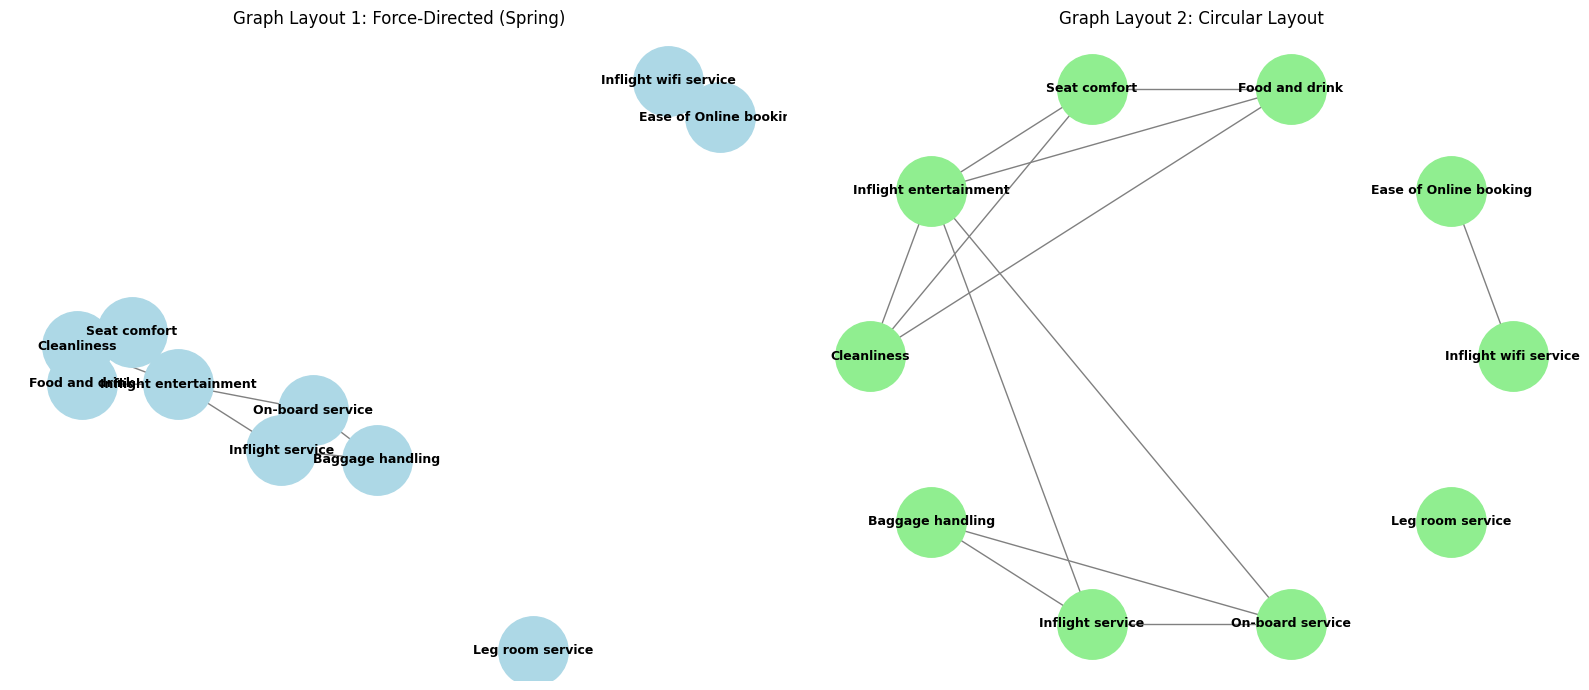

In [8]:
plt.figure(figsize=(16, 7))

# Graph Layout 1: Force-Directed Layout (Spring)
plt.subplot(1, 2, 1)
pos_spring = nx.spring_layout(G, seed=42)
nx.draw(G, pos_spring, with_labels=True, node_color='lightblue', node_size=2500, 
        font_size=9, font_weight='bold', edge_color='gray')
plt.title("Graph Layout 1: Force-Directed (Spring)")

# Graph Layout 2: Circular Layout
plt.subplot(1, 2, 2)
pos_circ = nx.circular_layout(G)
nx.draw(G, pos_circ, with_labels=True, node_color='lightgreen', node_size=2500, 
        font_size=9, font_weight='bold', edge_color='gray')
plt.title("Graph Layout 2: Circular Layout")

plt.tight_layout()
plt.show()